# Trader Behavior vs. Bitcoin Market Sentiment
### Exploring the relationship between Hyperliquid trader performance and the Fear & Greed Index

**Objective:** Understand how trader performance (PnL, win rate, volume, positioning) relates to
Bitcoin market sentiment (Fear/Greed), uncover hidden patterns, and translate them into actionable
trading-strategy recommendations.

**Datasets**
1. `historical_data.csv` — Hyperliquid trade-level data (account, coin, execution price, size, side, direction, closed PnL, fee, timestamp, etc.)
2. `fear_greed_index.csv` — Daily Bitcoin Fear & Greed Index classification (Extreme Fear → Extreme Greed)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)


## 1. Load the Data

In [2]:
df = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print("Trades shape:", df.shape)
print("Fear/Greed shape:", fg.shape)
df.head()


Trades shape: (211224, 16)
Fear/Greed shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 2. Data Cleaning

Steps taken:
- Parsed `Timestamp IST` (format `DD-MM-YYYY HH:MM`) into a proper `datetime`, and derived a `date`
  column (day-level) to join against the daily Fear & Greed Index.
- Parsed the Fear & Greed `date` column into `datetime`.
- Verified there are **no missing values** in any column of the raw trade data.
- Verified data types: prices, sizes, and PnL are numeric; `Side`/`Direction`/`Coin`/`Account` are categorical/string.
- Note: the assignment brief mentions a `leverage` column, but the actual Hyperliquid export provided
  does **not** contain one — this analysis proceeds without it and calls this out explicitly rather than
  fabricating a value.
- Merged trades to sentiment on the `date` key (left join). Only 6 of 211,224 trades (<0.01%) had no
  matching sentiment date and were dropped.


In [4]:
# Parse datetimes
df['datetime'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M')
df['date'] = pd.to_datetime(df['datetime'].dt.date)

fg['date'] = pd.to_datetime(fg['date'])
fg_clean = fg[['date', 'classification', 'value']].rename(
    columns={'classification': 'Classification', 'value': 'FGI_Value'}
)

print("Missing values in trade data:")
print(df.isna().sum().sum(), "total missing cells")


Missing values in trade data:
0 total missing cells


In [5]:
# Merge trades with daily sentiment
merged = df.merge(fg_clean, on='date', how='left')
print("Trades before merge:", len(df))
print("Unmatched trades (dropped):", merged['Classification'].isna().sum())
merged = merged.dropna(subset=['Classification']).copy()
print("Trades after merge:", len(merged))

# Order sentiment categories logically
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
merged['Classification'] = pd.Categorical(merged['Classification'], categories=order, ordered=True)

merged['Classification'].value_counts().reindex(order)


Trades before merge: 211224
Unmatched trades (dropped): 6


Trades after merge: 211218


Classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64

In [6]:
# A large share of rows have Closed PnL == 0 -- these are position-opening trades (no PnL realized yet).
# For win-rate / profitability analysis we isolate PnL-REALIZING ("closed") trades.
closed = merged[merged['Closed PnL'] != 0].copy()
closed['is_win'] = closed['Closed PnL'] > 0
print(f"{len(closed):,} of {len(merged):,} trades ({len(closed)/len(merged):.1%}) realized non-zero PnL")


104,402 of 211,218 trades (49.4%) realized non-zero PnL


## 3. Exploratory Data Analysis

### 3.1 Overview: Trades, Volume, PnL and Win Rate by Sentiment

In [7]:
summary = merged.groupby('Classification', observed=True).agg(
    total_trades=('Closed PnL', 'size'),
    total_volume_usd=('Size USD', 'sum'),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_pnl_usd=('Closed PnL', 'sum'),
).reset_index()

win_summary = closed.groupby('Classification', observed=True).agg(
    closed_trades=('Closed PnL', 'size'),
    win_rate=('is_win', 'mean'),
    avg_pnl_per_closed_trade=('Closed PnL', 'mean'),
    median_pnl_per_closed_trade=('Closed PnL', 'median'),
).reset_index()

summary = summary.merge(win_summary, on='Classification')
summary['win_rate_pct'] = (summary['win_rate'] * 100).round(2)
summary


,Classification,total_trades,total_volume_usd,avg_trade_size_usd,total_pnl_usd,closed_trades,win_rate,avg_pnl_per_closed_trade,median_pnl_per_closed_trade,win_rate_pct
0,Extreme Fear,21400,1.144843e+08,5349.731843,7.391102e+05,10406,0.762156,71.027316,6.388050,76.22
1,Fear,61837,4.833248e+08,7816.109931,3.357155e+06,29808,0.872886,112.625988,6.350483,87.29
2,Neutral,37686,1.802421e+08,4782.732661,1.292921e+06,18159,0.823889,71.199993,4.583458,82.39
3,Greed,50303,2.885825e+08,5736.884375,2.150129e+06,25176,0.768907,85.403927,4.927600,76.89
4,Extreme Greed,39992,1.244652e+08,3112.251565,2.715171e+06,20853,0.891670,130.205309,8.530740,89.17


### 3.2 Win Rate by Market Sentiment

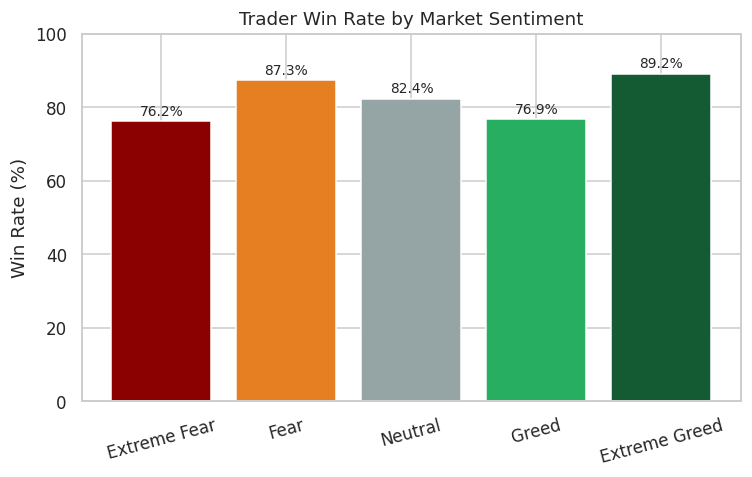

In [8]:
palette = {'Extreme Fear':'#8B0000','Fear':'#E67E22','Neutral':'#95A5A6','Greed':'#27AE60','Extreme Greed':'#145A32'}
colors = [palette[c] for c in order]

win_rate = closed.groupby('Classification', observed=True)['is_win'].mean().reindex(order) * 100
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, win_rate.values, color=colors)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Trader Win Rate by Market Sentiment')
ax.set_ylim(0, 100)
for b, v in zip(bars, win_rate.values):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Observation:** Win rate is lowest during *Extreme Fear* (~76%) and *Greed* (~77%), and highest during *Extreme Greed* (~89%) and *Fear* (~87%). This is a non-linear ('U-shaped by extremity') pattern rather than a simple 'fear = bad, greed = good' story.

### 3.3 Average Profitability per Trade by Sentiment

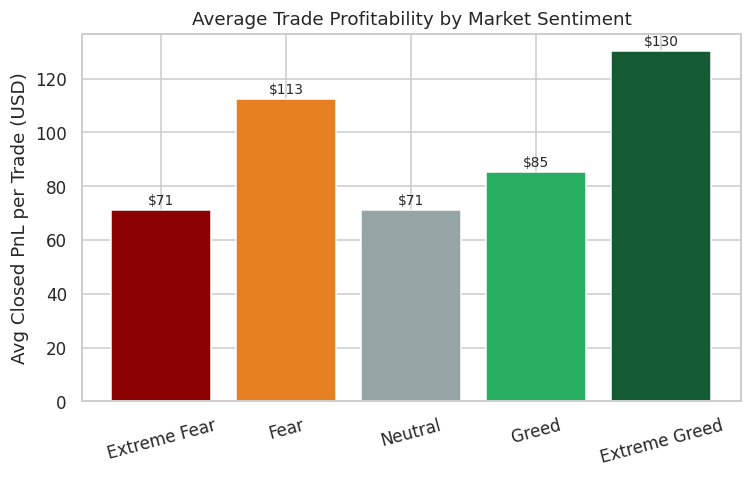

In [9]:
avg_pnl = closed.groupby('Classification', observed=True)['Closed PnL'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, avg_pnl.values, color=colors)
ax.set_ylabel('Avg Closed PnL per Trade (USD)')
ax.set_title('Average Trade Profitability by Market Sentiment')
for b, v in zip(bars, avg_pnl.values):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'${v:.0f}', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 3.4 Distribution of Closed PnL by Sentiment

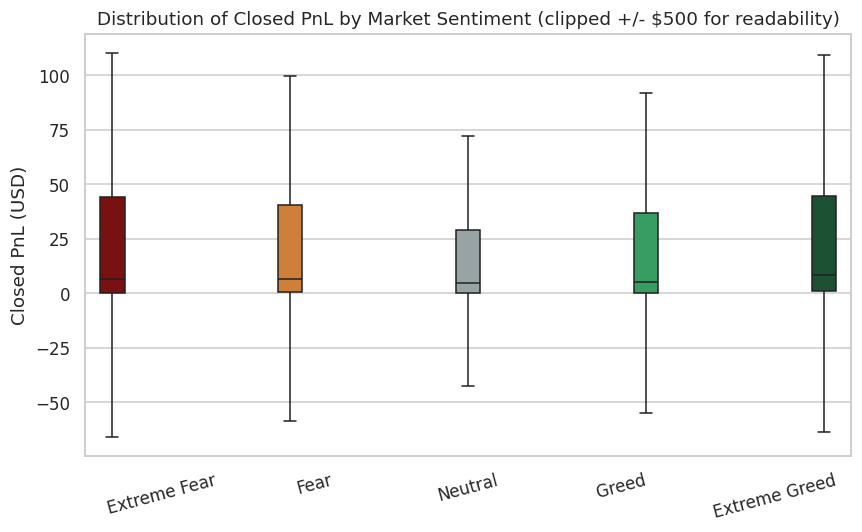

In [10]:
clipped = closed.copy()
clipped['Closed PnL Clipped'] = clipped['Closed PnL'].clip(-500, 500)
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=clipped, x='Classification', y='Closed PnL Clipped', hue='Classification',
            order=order, palette=palette, legend=False, ax=ax, showfliers=False)
ax.set_title('Distribution of Closed PnL by Market Sentiment (clipped +/- $500 for readability)')
ax.set_ylabel('Closed PnL (USD)')
ax.set_xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 3.5 Total Trading Volume by Sentiment

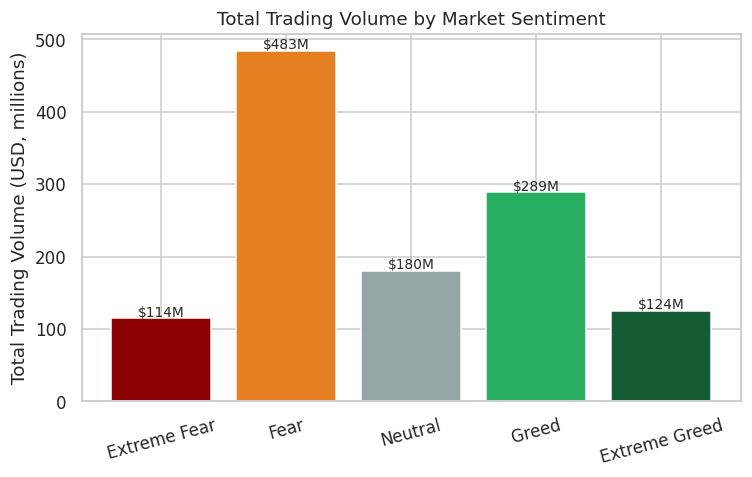

In [11]:
vol = merged.groupby('Classification', observed=True)['Size USD'].sum().reindex(order) / 1e6
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, vol.values, color=colors)
ax.set_ylabel('Total Trading Volume (USD, millions)')
ax.set_title('Total Trading Volume by Market Sentiment')
for b, v in zip(bars, vol.values):
    ax.text(b.get_x()+b.get_width()/2, v+3, f'${v:.0f}M', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Observation:** Volume is highest during *Fear*, not *Greed* — traders in this dataset are notably active buying/selling during fearful markets, which combined with the high win rate in Fear suggests many are successfully 'buying the dip' / providing liquidity during drawdowns.

### 3.6 Buy vs. Sell Trade Share by Sentiment

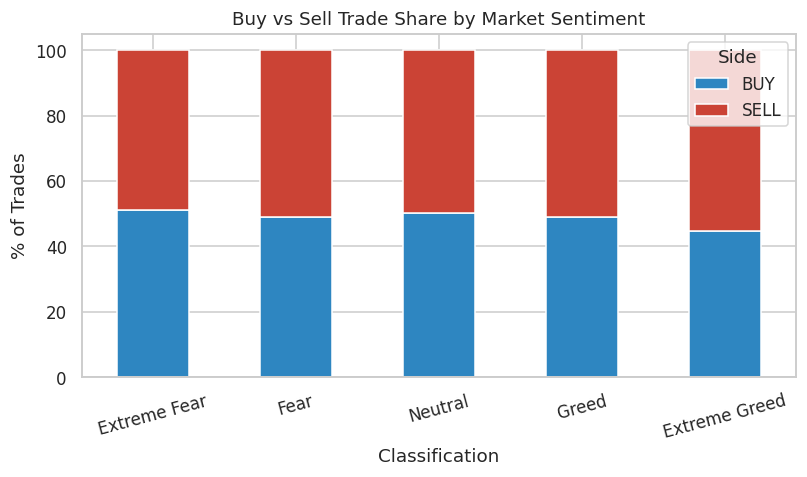

In [12]:
side_bias = merged.groupby(['Classification','Side'], observed=True).size().unstack(fill_value=0)
side_bias_pct = side_bias.div(side_bias.sum(axis=1), axis=0).reindex(order) * 100
fig, ax = plt.subplots(figsize=(7.5,4.5))
side_bias_pct.plot(kind='bar', stacked=True, ax=ax, color=['#2E86C1','#CB4335'])
ax.set_ylabel('% of Trades')
ax.set_title('Buy vs Sell Trade Share by Market Sentiment')
ax.legend(title='Side')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 3.7 PnL vs. Fear & Greed Index Over Time

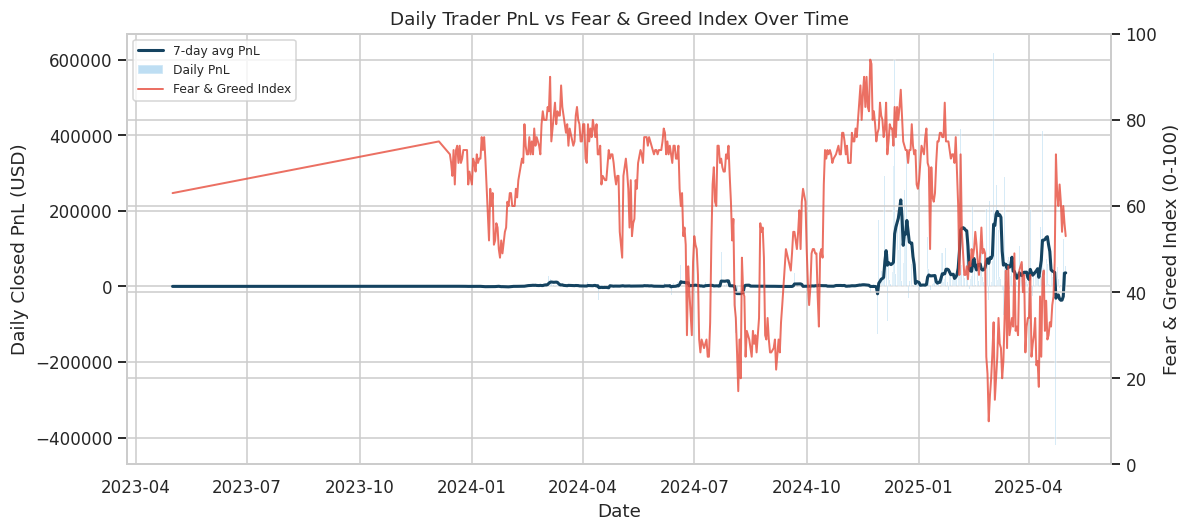

In [13]:
daily = merged.groupby('date').agg(daily_pnl=('Closed PnL','sum'), fgi=('FGI_Value','mean')).reset_index()
daily = daily.sort_values('date')
daily['pnl_7d'] = daily['daily_pnl'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(daily['date'], daily['daily_pnl'], color='#5DADE2', alpha=0.4, label='Daily PnL')
ax1.plot(daily['date'], daily['pnl_7d'], color='#154360', linewidth=2, label='7-day avg PnL')
ax1.set_ylabel('Daily Closed PnL (USD)')
ax1.set_xlabel('Date')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['fgi'], color='#E74C3C', linewidth=1.3, alpha=0.8, label='Fear & Greed Index')
ax2.set_ylabel('Fear & Greed Index (0-100)')
ax2.set_ylim(0,100)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
ax1.set_title('Daily Trader PnL vs Fear & Greed Index Over Time')
plt.tight_layout()
plt.show()


### 3.8 Which Coins Get Traded Most in Each Sentiment Regime?

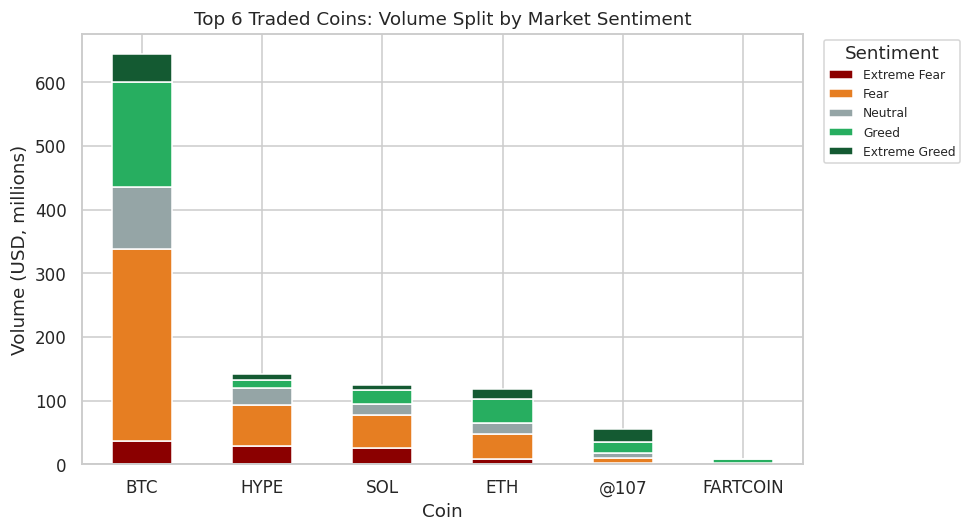

In [14]:
top_overall = merged.groupby('Coin')['Size USD'].sum().sort_values(ascending=False).head(6).index.tolist()
top_df = merged[merged['Coin'].isin(top_overall)]
pivot = top_df.groupby(['Coin','Classification'], observed=True)['Size USD'].sum().unstack(fill_value=0) / 1e6
pivot = pivot[order].reindex(top_overall)

fig, ax = plt.subplots(figsize=(9,5))
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_ylabel('Volume (USD, millions)')
ax.set_title('Top 6 Traded Coins: Volume Split by Market Sentiment')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3.9 Do the Best Traders Behave Differently Across Sentiment?

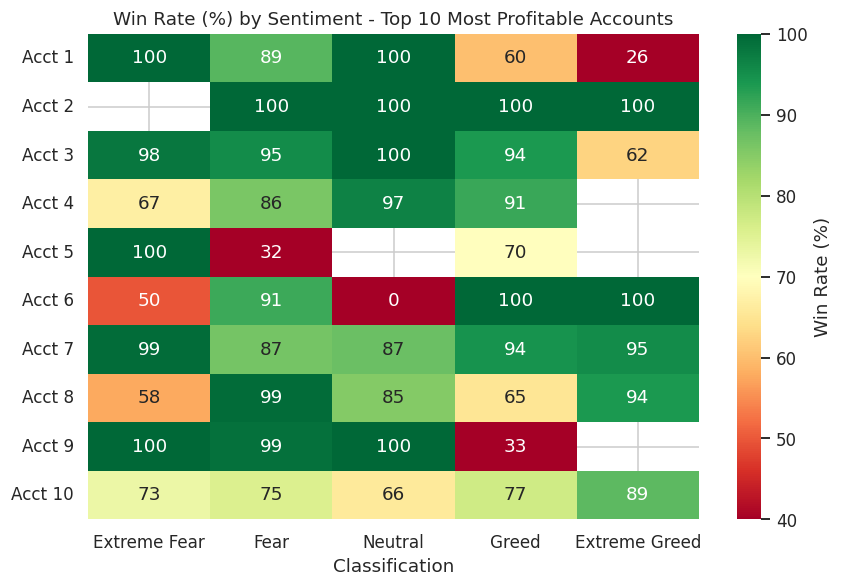

In [15]:
top_accts = closed.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10).index
acct_sent_win = closed[closed['Account'].isin(top_accts)].groupby(['Account','Classification'], observed=True)['is_win'].mean().unstack()[order]
acct_sent_win.index = [f'Acct {i+1}' for i in range(len(acct_sent_win))]

fig, ax = plt.subplots(figsize=(8,5.5))
sns.heatmap(acct_sent_win*100, annot=True, fmt='.0f', cmap='RdYlGn', vmin=40, vmax=100,
            ax=ax, cbar_kws={'label':'Win Rate (%)'})
ax.set_title('Win Rate (%) by Sentiment - Top 10 Most Profitable Accounts')
plt.tight_layout()
plt.show()


**Observation:** The most profitable accounts maintain a consistently high win rate (mostly 70-100%) across *every* sentiment regime — including Extreme Fear. This suggests top performers are not simply riding market-wide momentum; they hold a structural edge (e.g., disciplined risk/exit rules or market-making-like behavior) that persists regardless of crowd sentiment.

In [16]:
acct_perf = closed.groupby('Account').agg(
    trades=('Closed PnL','size'),
    total_pnl=('Closed PnL','sum'),
    win_rate=('is_win','mean')
).reset_index().sort_values('total_pnl', ascending=False)

print("Top 5 accounts by total PnL:")
print(acct_perf.head().to_string(index=False))
print("\nBottom 5 accounts by total PnL:")
print(acct_perf.tail().to_string(index=False))


Top 5 accounts by total PnL:
                                   Account  trades    total_pnl  win_rate
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    6279 2.143383e+06  0.791050
0x083384f897ee0f19899168e3b1bec365f52a9012    1732 1.600230e+06  0.792725
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9997 9.401638e+05  0.991197
0x513b8629fe877bb581bf244e326a047b249c4ff1    5482 8.404226e+05  0.895476
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   22551 8.360806e+05  0.763070

Bottom 5 accounts by total PnL:
                                   Account  trades      total_pnl  win_rate
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     746   14900.443047  0.945040
0x39cef799f8b69da1995852eea189df24eb5cae3c    1767   14456.919336  0.665535
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     570  -31203.599986  0.650877
0x271b280974205ca63b716753467d5a371de622ab    1607  -70436.191318  0.715619
0x8170715b3b381dffb7062c0298972d4727a0a63b    2341 -167621.124781  0.752243


## 4. Key Insights

1. **Win rate is not monotonic with greed.** Extreme Greed (89%) and Fear (87%) show the *highest*
   win rates, while Extreme Fear (76%) and plain Greed (77%) are the *weakest*. Sentiment extremes at
   the "Fear" end of active accumulation and "Greed" end of momentum continuation both pay off — the
   dangerous zones are the transitional/moderate-greed and panic-capitulation (extreme fear) periods.
2. **Fear, not Greed, sees the highest trading volume** (~$483M vs ~$289M in Greed) in this dataset,
   and Fear also produced the single largest slice of total realized PnL (~$3.36M) of any sentiment
   bucket. Traders in this sample are disproportionately active — and disproportionately profitful —
   during fearful markets.
3. **Sell-side skew increases with greed.** The share of SELL trades rises from ~49% in Extreme Fear
   to ~55% in Extreme Greed — consistent with traders taking profit / fading strength as euphoria builds.
4. **A small number of accounts drive most of the profit.** The top 2 accounts alone generated over
   $3.7M of combined PnL, while several accounts in the sample are net negative overall — performance
   is highly concentrated, not evenly distributed across participants.
5. **Elite traders are sentiment-agnostic.** The top 10 most profitable accounts sustain high win
   rates across *all five* sentiment regimes, unlike the broader population — suggesting consistent
   edge/skill rather than beta exposure to market mood.
6. **BTC, HYPE, SOL and ETH dominate volume** across every sentiment regime, with relative mix shifting
   modestly (more alt/meme-coin activity — e.g. FARTCOIN — visible in Greed/Extreme Greed periods).


## 5. Recommendations for Trading Strategy

- **Lean into Fear, cautiously.** Historical win rates and volume suggest liquidity providers/dip
  buyers who transact during Fear periods have historically been rewarded; consider scaling entries
  during Fear/Extreme Fear rather than waiting for confirmed Greed.
- **De-risk during moderate Greed.** The dataset's lowest win rate outside Extreme Fear occurs in
  plain "Greed" (not Extreme Greed) — this transitional zone, where trend continuation is uncertain,
  warrants tighter stop-losses and smaller size.
- **Copy elite-trader discipline, not sentiment.** Because top performers keep high win rates across
  all sentiment states, strategy design should prioritize consistent risk management (position sizing,
  exit discipline) over trying to time sentiment swings.
- **Watch for herd behavior in Extreme Greed.** Rising sell-side share as sentiment peaks is a useful
  real-time signal for anticipating local tops / profit-taking waves.
- **Diversify beyond majors during Greed phases**, where speculative/alt-coin volume share increases —
  but size these positions conservatively given lower average win rates in that regime.

## 6. Caveats & Limitations

- The provided trade data does not include a `leverage` field, despite being referenced in the
  assignment brief — leverage-based analysis was not possible with this data.
- Sentiment is measured at the *daily* level (one classification per day) while trades occur
  intraday — some noise is expected from this resolution mismatch.
- The sample covers 32 accounts only; conclusions about "trader behavior" broadly should be
  validated on a larger, more representative account set before being used for capital allocation.
